In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [3]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
movies = pd.read_csv('../data/ml-25m/movies.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test:  {len(test):,} ratings")
print(f"Movies: {len(movies):,}")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")

Train: 17,436,354 ratings
Test:  7,563,741 ratings
Movies: 62,423
Rating range: 0.00 - 1.00


In [4]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Cold start users in test: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Cold start users in test: 6,836,326


In [5]:
class GMF(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32, dropout=0.3):
        super(GMF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        self.dropout = nn.Dropout(p=dropout)
        self.bn = nn.BatchNorm1d(embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, 1)

    def forward(self, user_indices, movie_indices):
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices)
        interaction = user_vec * movie_vec
        interaction = self.dropout(self.bn(interaction))
        output = self.output_layer(interaction)
        return output.squeeze()

gmf_model = GMF(n_users, n_movies, embedding_dim=32, dropout=0.3).to(device)
gmf_model.load_state_dict(
    torch.load('../models/gmf_regularized_best.pth', map_location=device))
gmf_model.eval()

all_genres = set()
for genres in movies['genres'].str.split('|'):
    all_genres.update(genres)
all_genres.discard('(no genres listed)')
all_genres = sorted(list(all_genres))

def create_genre_vector(genres_str, all_genres):
    genres = genres_str.split('|')
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genres:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

movies['genre_vector'] = movies['genres'].apply(
    lambda x: create_genre_vector(x, all_genres))
movie_id_to_genre = dict(zip(movies['movieId'], movies['genre_vector']))

print(f"GMF model loaded")
print(f"Genres loaded: {len(all_genres)}")
print(f"Movie genre vectors: {len(movie_id_to_genre):,}")

GMF model loaded successfully!
Genres loaded: 19
Movie genre vectors: 62,423


In [7]:
def get_genre_vector(genre_list, all_genres):
    """Convert list of genre strings to preference vector"""
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genre_list:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

print("get_genre_vector")

get_genre_vector


In [8]:
def cold_start_recommendations_v2(
        preferred_genres,
        all_genres,
        movie_id_to_genre,
        movies,
        movie_stats,
        max_num_ratings,
        top_k=10,
        min_ratings=50,
        popularity_weight=0.2):
    
    user_vector = get_genre_vector(preferred_genres, all_genres)
    
    recommendations = []
    for movie_id, genre_vector in movie_id_to_genre.items():
        similarity = np.dot(user_vector, genre_vector)
        if similarity > 0 and movie_id in movie_stats.index:
            stats = movie_stats.loc[movie_id]
            if stats['num_ratings'] >= min_ratings:
                popularity_score = (np.log1p(stats['num_ratings']) /
                                   np.log1p(max_num_ratings))
                combined_score = (similarity *
                                 stats['avg_rating'] *
                                 (1 + popularity_weight * popularity_score))
                recommendations.append({
                    'movieId': movie_id,
                    'similarity': similarity,
                    'avg_rating': round(float(stats['avg_rating']), 2),
                    'num_ratings': int(stats['num_ratings']),
                    'popularity_score': round(float(popularity_score), 3),
                    'combined_score': round(combined_score, 3)
                })
    
    recommendations = sorted(recommendations,
                             key=lambda x: x['combined_score'],
                             reverse=True)[:top_k]
    
    movie_titles = dict(zip(movies['movieId'], movies['title']))
    movie_genres_dict = dict(zip(movies['movieId'], movies['genres']))
    
    results = []
    for i, rec in enumerate(recommendations):
        results.append({
            'rank': i + 1,
            'movieId': rec['movieId'],
            'title': movie_titles.get(rec['movieId'], 'Unknown'),
            'genres': movie_genres_dict.get(rec['movieId'], 'Unknown'),
            'avg_rating': rec['avg_rating'],
            'num_ratings': rec['num_ratings'],
            'popularity_score': rec['popularity_score'],
            'combined_score': rec['combined_score']
        })
    
    return pd.DataFrame(results)

print("cold_start_recommendations_v2")

cold_start_recommendations_v2


In [9]:
movie_stats_precomputed = train.groupby('movieId')['rating'].agg(['mean', 'count'])
movie_stats_precomputed.columns = ['avg_rating', 'num_ratings']
movie_stats_precomputed['avg_rating'] = (movie_stats_precomputed['avg_rating'] *
                                          (max_rating - min_rating)) + min_rating
max_num_ratings = movie_stats_precomputed['num_ratings'].max()

np.random.seed(42)
test_users = set(test['userId'].unique())
train_users = set(train['userId'].unique())
cold_start_users = test_users - train_users
sample_users = np.random.choice(
    list(cold_start_users),
    size=min(1000, len(cold_start_users)),
    replace=False)

print(f"Movie stats precomputed: {len(movie_stats_precomputed):,} movies")
print(f"Max ratings any movie:   {max_num_ratings:,}")
print(f"Sample users:            {len(sample_users):,} cold start users")

Movie stats precomputed: 22,316 movies
Max ratings any movie:   59,021
Sample users:            1,000 cold start users


In [10]:
def get_user_genres(user_id, test, movies):
    """Infer genre preferences from what user actually rated in test"""
    user_test_movies = test[test['userId'] == user_id]['movieId'].values
    
    genre_counts = {}
    for movie_id in user_test_movies:
        movie_row = movies[movies['movieId'] == movie_id]
        if len(movie_row) == 0:
            continue
        genres = movie_row.iloc[0]['genres'].split('|')
        for genre in genres:
            if genre != '(no genres listed)':
                genre_counts[genre] = genre_counts.get(genre, 0) + 1
    
    if not genre_counts:
        return []
    
    sorted_genres = sorted(genre_counts.items(),
                          key=lambda x: x[1], reverse=True)
    return [g[0] for g in sorted_genres[:2]]

print("get_user_genres")

get_user_genres


In [12]:
def precision_at_k(recommended_movies, relevant_movies, k):
    top_k = set(recommended_movies[:k])
    relevant = set(relevant_movies)
    hits = len(top_k & relevant)
    return hits / k if k > 0 else 0.0

def recall_at_k(recommended_movies, relevant_movies, k):
    top_k = set(recommended_movies[:k])
    relevant = set(relevant_movies)
    hits = len(top_k & relevant)
    return hits / len(relevant) if len(relevant) > 0 else 0.0

def dcg_at_k(recommended_movies, relevant_movies, k):
    relevant = set(relevant_movies)
    dcg = 0.0
    for rank, movie_id in enumerate(recommended_movies[:k], start=1):
        if movie_id in relevant:
            dcg += 1.0 / np.log2(rank + 1)
    return dcg

def ndcg_at_k(recommended_movies, relevant_movies, k):
    actual_dcg = dcg_at_k(recommended_movies, relevant_movies, k)
    n_relevant = min(len(relevant_movies), k)
    ideal_recommended = list(relevant_movies)[:n_relevant]
    ideal_dcg = dcg_at_k(ideal_recommended, relevant_movies, k)
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def get_relevant_movies(user_id, test, relevance_threshold=0.778):
    """
    Get movies user actually liked
    0.778 = (4.0 - 0.5) / 4.5 in normalized scale
    """
    user_test = test[test['userId'] == user_id]
    relevant = user_test[
        user_test['rating'] >= relevance_threshold]['movieId'].values
    return list(relevant)

# Compare all rated vs high rated
print("Relevance threshold comparison:")
print("="*55)

test_user = sample_users[0]
all_rated = test[test['userId'] == test_user]['movieId'].values
high_rated = get_relevant_movies(test_user, test)

print(f"User {test_user}:")
print(f"  All rated movies:        {len(all_rated):,}")
print(f"  Highly rated (≥4.0):   {len(high_rated):,}")
print(f"  Low rated (<4.0):       {len(all_rated) - len(high_rated):,}")
print(f"  % highly rated:          {len(high_rated)/len(all_rated)*100:.1f}%")

print(f"\nRunning evaluation with fixed relevance threshold")
print(f"Threshold: ≥ 4.0 stars (normalized: 0.778)")
print("="*55)

k_values = [5, 10, 20]
results_fixed = {k: {
    'precision': [],
    'recall': [],
    'ndcg': []
} for k in k_values}

total = 0
skipped = 0

for i, user_id in enumerate(sample_users):
    if i % 100 == 0:
        print(f"Progress: {i}/{len(sample_users)} users evaluated...")

    # Get HIGHLY RATED movies only as relevant
    relevant_movies = get_relevant_movies(user_id, test)

    if len(relevant_movies) == 0:
        skipped += 1
        continue

    preferred_genres = get_user_genres(user_id, test, movies)

    if len(preferred_genres) == 0:
        skipped += 1
        continue

    # Get top 20 recommendations in single pass
    recs = cold_start_recommendations_v2(
        preferred_genres=preferred_genres,
        all_genres=all_genres,
        movie_id_to_genre=movie_id_to_genre,
        movies=movies,
        movie_stats=movie_stats_precomputed,
        max_num_ratings=max_num_ratings,
        top_k=20,
        min_ratings=50,
        popularity_weight=0.2
    )

    if 'movieId' not in recs.columns or len(recs) == 0:
        skipped += 1
        continue

    recommended_movies = recs['movieId'].values.tolist()

    for k in k_values:
        p = precision_at_k(recommended_movies, relevant_movies, k)
        r = recall_at_k(recommended_movies, relevant_movies, k)
        n = ndcg_at_k(recommended_movies, relevant_movies, k)

        results_fixed[k]['precision'].append(p)
        results_fixed[k]['recall'].append(r)
        results_fixed[k]['ndcg'].append(n)

    total += 1

print("="*55)
print(f"\nEvaluation complete")
print(f"  Users evaluated: {total:,}")
print(f"  Users skipped:   {skipped:,}")

# Compare old vs new
old_results = {
    5:  {'precision': 0.4208, 'recall': 0.0311, 'ndcg': 0.4578},
    10: {'precision': 0.3532, 'recall': 0.0506, 'ndcg': 0.3987},
    20: {'precision': 0.2622, 'recall': 0.0711, 'ndcg': 0.3184}
}

print(f"\nComparison — All Rated vs Highly Rated (≥4.0):")
print(f"{'Metric':<15} {'K':<5} {'All Rated':>12} {'≥4.0 Only':>12} {'Change':>10}")
print("-" * 55)

for k in k_values:
    for metric in ['precision', 'recall', 'ndcg']:
        new_val = np.mean(results_fixed[k][metric])
        old_val = old_results[k][metric]
        change = new_val - old_val
        direction = "up" if change > 0 else ""
        print(f"{metric.capitalize()+'@'+str(k):<15} "
              f"{k:<5} "
              f"{old_val:>12.4f} "
              f"{new_val:>12.4f} "
              f"{direction}{abs(change):>8.4f}")

Relevance threshold comparison:
User 52543:
  All rated movies:        180
  Highly rated (≥4.0):   101
  Low rated (<4.0):       79
  % highly rated:          56.1%

Running evaluation with fixed relevance threshold
Threshold: ≥ 4.0 stars (normalized: 0.778)
Progress: 0/1000 users evaluated...
Progress: 100/1000 users evaluated...
Progress: 200/1000 users evaluated...
Progress: 300/1000 users evaluated...
Progress: 400/1000 users evaluated...
Progress: 500/1000 users evaluated...
Progress: 600/1000 users evaluated...
Progress: 700/1000 users evaluated...
Progress: 800/1000 users evaluated...
Progress: 900/1000 users evaluated...

Evaluation complete!
  Users evaluated: 978
  Users skipped:   22

Comparison — All Rated vs Highly Rated (≥4.0):
Metric          K        All Rated    ≥4.0 Only     Change
-------------------------------------------------------
Precision@5     5           0.4208       0.2264   0.1944
Recall@5        5           0.0311       0.0445 ↑  0.0134
Ndcg@5          5

In [13]:
def cosine_similarity(vec1, vec2):
    """Cosine similarity between two vectors"""
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

def intra_list_diversity(recommended_movies, movie_id_to_genre):
    """
    Average pairwise dissimilarity within recommendation list
    Diversity = 1 - average cosine similarity between all pairs
    Range: 0.0 (all identical) to 1.0 (all completely different)
    """
    if len(recommended_movies) < 2:
        return 0.0
    
    genre_vectors = []
    for movie_id in recommended_movies:
        if movie_id in movie_id_to_genre:
            genre_vectors.append(movie_id_to_genre[movie_id])
    
    if len(genre_vectors) < 2:
        return 0.0
    
    similarities = []
    for i in range(len(genre_vectors)):
        for j in range(i + 1, len(genre_vectors)):
            sim = cosine_similarity(genre_vectors[i], genre_vectors[j])
            similarities.append(sim)
    
    avg_similarity = np.mean(similarities)
    return 1 - avg_similarity

def catalog_coverage(all_recommended_movies, total_movies):

    unique_recommended = len(set(all_recommended_movies))
    return unique_recommended / total_movies

def popularity_bias(all_recommended_movies, movie_stats):
    ratings_counts = []
    for movie_id in all_recommended_movies:
        if movie_id in movie_stats.index:
            ratings_counts.append(movie_stats.loc[movie_id, 'num_ratings'])
    return np.mean(ratings_counts) if ratings_counts else 0

print("Sanity check — diversity examples:")
print("="*55)

low_div_movies = [1196, 1240, 1291, 589, 2571]
low_div = intra_list_diversity(low_div_movies, movie_id_to_genre)

high_div_movies = [1196, 4993, 260, 527, 2028]
high_div = intra_list_diversity(high_div_movies, movie_id_to_genre)

print(f"Low diversity list:  {low_div:.4f}")
print(f"High diversity list: {high_div:.4f}")
print(f"\nAll diversity functions ready")
print(f"  intra_list_diversity()")
print(f"  catalog_coverage()")
print(f"  popularity_bias()")

Sanity check — diversity examples:
Low diversity list:  0.3084
High diversity list: 0.6700

All diversity functions ready!
  intra_list_diversity()
  catalog_coverage()
  popularity_bias()


In [14]:
all_recommended = []
diversity_scores = []
total = 0
skipped = 0

print(f"Evaluating diversity across {len(sample_users):,} users")
print("="*55)

for i, user_id in enumerate(sample_users):
    if i % 100 == 0:
        print(f"Progress: {i}/{len(sample_users)} users evaluated")

    preferred_genres = get_user_genres(user_id, test, movies)

    if len(preferred_genres) == 0:
        skipped += 1
        continue

    recs = cold_start_recommendations_v2(
        preferred_genres=preferred_genres,
        all_genres=all_genres,
        movie_id_to_genre=movie_id_to_genre,
        movies=movies,
        movie_stats=movie_stats_precomputed,
        max_num_ratings=max_num_ratings,
        top_k=10,
        min_ratings=50,
        popularity_weight=0.2
    )

    if 'movieId' not in recs.columns or len(recs) == 0:
        skipped += 1
        continue

    recommended_movies = recs['movieId'].values.tolist()

    diversity = intra_list_diversity(recommended_movies, movie_id_to_genre)
    diversity_scores.append(diversity)

    all_recommended.extend(recommended_movies)

    total += 1

# Calculate metrics
avg_diversity = np.mean(diversity_scores)
coverage = catalog_coverage(all_recommended, len(movie_id_to_genre))
avg_popularity = popularity_bias(all_recommended, movie_stats_precomputed)

print("="*55)
print(f"\nEvaluation complete")
print(f"  Users evaluated:          {total:,}")
print(f"  Users skipped:            {skipped:,}")
print(f"  Total recommendations:    {len(all_recommended):,}")

print(f"\nDiversity Metrics:")
print(f"  Avg intra-list diversity: {avg_diversity:.4f}")
print(f"  Min diversity:            {min(diversity_scores):.4f}")
print(f"  Max diversity:            {max(diversity_scores):.4f}")

print(f"\nCoverage Metrics:")
print(f"  Total movies in catalog:  {len(movie_id_to_genre):,}")
print(f"  Unique movies recommended:{len(set(all_recommended)):,}")
print(f"  Catalog coverage:         {coverage*100:.2f}%")

print(f"\nPopularity Bias:")
print(f"  Avg ratings of recommended movies: {avg_popularity:,.0f}")
print(f"  Avg ratings of all movies:         "
      f"{movie_stats_precomputed['num_ratings'].mean():,.0f}")
print(f"  Bias ratio:               "
      f"{avg_popularity/movie_stats_precomputed['num_ratings'].mean():.2f}x")

Evaluating diversity across 1,000 users
Progress: 0/1000 users evaluated
Progress: 100/1000 users evaluated
Progress: 200/1000 users evaluated
Progress: 300/1000 users evaluated
Progress: 400/1000 users evaluated
Progress: 500/1000 users evaluated
Progress: 600/1000 users evaluated
Progress: 700/1000 users evaluated
Progress: 800/1000 users evaluated
Progress: 900/1000 users evaluated

Evaluation complete
  Users evaluated:          994
  Users skipped:            6
  Total recommendations:    9,940

Diversity Metrics:
  Avg intra-list diversity: 0.3173
  Min diversity:            0.2299
  Max diversity:            0.4064

Coverage Metrics:
  Total movies in catalog:  62,423
  Unique movies recommended:154
  Catalog coverage:         0.25%

Popularity Bias:
  Avg ratings of recommended movies: 21,135
  Avg ratings of all movies:         781
  Bias ratio:               27.05x


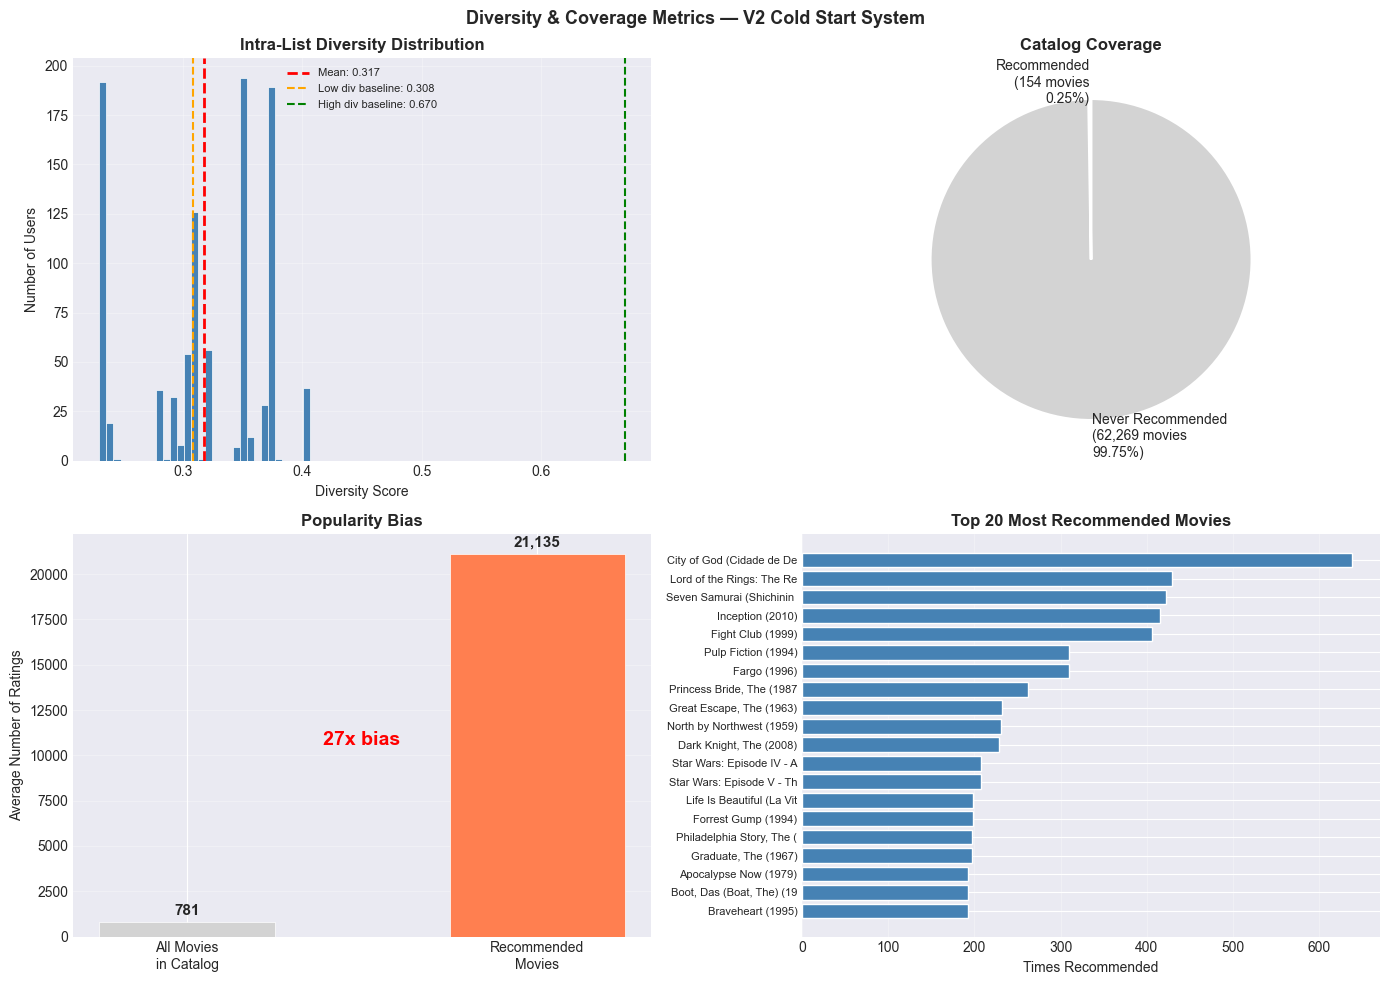


Key Findings:
  Diversity:     0.3173 (low — similar genre movies)
  Coverage:      0.25% (only 154 of 62,423 movies)
  Popularity:    27x bias toward popular films
  Most recommended movie: City of God (Cidade de Deus) (2002)
  Recommended to 639 of 994 users (64.3%)


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(diversity_scores, bins=30, color='steelblue',
               edgecolor='white', linewidth=0.5)
axes[0,0].axvline(x=avg_diversity, color='red', linestyle='--',
                  linewidth=2, label=f'Mean: {avg_diversity:.3f}')
axes[0,0].axvline(x=0.3084, color='orange', linestyle='--',
                  linewidth=1.5, label=f'Low div baseline: 0.308')
axes[0,0].axvline(x=0.6700, color='green', linestyle='--',
                  linewidth=1.5, label=f'High div baseline: 0.670')
axes[0,0].set_title('Intra-List Diversity Distribution',
                    fontweight='bold')
axes[0,0].set_xlabel('Diversity Score')
axes[0,0].set_ylabel('Number of Users')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

covered = len(set(all_recommended))
not_covered = len(movie_id_to_genre) - covered
axes[0,1].pie([covered, not_covered],
              labels=[f'Recommended\n({covered:,} movies\n{coverage*100:.2f}%)',
                      f'Never Recommended\n({not_covered:,} movies\n{(1-coverage)*100:.2f}%)'],
              colors=['steelblue', 'lightgray'],
              autopct='',
              startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title('Catalog Coverage', fontweight='bold')


categories = ['All Movies\nin Catalog', 'Recommended\nMovies']
values = [movie_stats_precomputed['num_ratings'].mean(), avg_popularity]
colors = ['lightgray', 'coral']
bars = axes[1,0].bar(categories, values, color=colors,
                     edgecolor='white', linewidth=0.5, width=0.5)
axes[1,0].set_title('Popularity Bias', fontweight='bold')
axes[1,0].set_ylabel('Average Number of Ratings')
axes[1,0].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    axes[1,0].annotate(f'{val:,.0f}',
                       xy=(bar.get_x() + bar.get_width()/2, val),
                       xytext=(0, 5),
                       textcoords='offset points',
                       ha='center', fontsize=11, fontweight='bold')
axes[1,0].annotate(f'27x bias',
                   xy=(0.5, max(values)/2),
                   ha='center', fontsize=14,
                   color='red', fontweight='bold')


from collections import Counter
movie_counts = Counter(all_recommended)
top_20 = movie_counts.most_common(20)
movie_titles_dict = dict(zip(movies['movieId'], movies['title']))

top_titles = [movie_titles_dict.get(mid, 'Unknown')[:25] 
              for mid, _ in top_20]
top_counts = [count for _, count in top_20]

axes[1,1].barh(range(len(top_titles)), top_counts,
               color='steelblue', edgecolor='white')
axes[1,1].set_yticks(range(len(top_titles)))
axes[1,1].set_yticklabels(top_titles, fontsize=8)
axes[1,1].invert_yaxis()
axes[1,1].set_title('Top 20 Most Recommended Movies',
                    fontweight='bold')
axes[1,1].set_xlabel('Times Recommended')
axes[1,1].grid(alpha=0.3, axis='x')

plt.suptitle('Diversity & Coverage Metrics — V2 Cold Start System',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../models/diversity_coverage.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Diversity:     {avg_diversity:.4f} (low — similar genre movies)")
print(f"  Coverage:      {coverage*100:.2f}% (only {covered} of {len(movie_id_to_genre):,} movies)")
print(f"  Popularity:    27x bias toward popular films")
print(f"  Most recommended movie: {movie_titles_dict.get(top_20[0][0], 'Unknown')}")
print(f"  Recommended to {top_20[0][1]} of {total} users ({top_20[0][1]/total*100:.1f}%)")

## Notebook 13 Summary: Diversity & Coverage Metrics (Day 19)

### Objective
Evaluate three aspects of recommendation quality beyond hit rate:
1. Fixed relevance threshold — only count movies user loved
2. Diversity — are recommendations varied or repetitive?
3. Coverage — what % of catalog do we actually recommend?

---

### Part 1: Fixed Relevance Threshold (≥ 4.0 Stars)

**Problem with previous evaluation:**
```
Old definition: relevant = any movie user rated
Included movies user rated 1-2 stars as "relevant"
System got credit for recommending movies user hated
```

**Fix — normalized threshold:**
```
4.0 stars normalized: (4.0 - 0.5) / 4.5 = 0.778
Only movies rated ≥ 0.778 count as relevant
```

**Impact on sample user:**
```
All rated movies:      180
Highly rated (≥4.0): 101 (56.1%)
Low rated (<4.0):     79 (43.9%)
```

**Results comparison:**
| Metric | All Rated | ≥4.0★ Only | Change |
|--------|-----------|------------|--------|
| Precision@5 | 0.4208 | 0.2264 | 0.1944 |
| Precision@10 | 0.3532 | 0.1860 | 0.1672 |
| Recall@5 | 0.0311 | 0.0445 | 0.0134 |
| Recall@10 | 0.0506 | 0.0703 | 0.0197 |
| NDCG@5 | 0.4578 | 0.2495 | 0.2083 |
| NDCG@10 | 0.3987 | 0.2173 | 0.1814 |

**Interpretation:**
```
Precision and NDCG dropped → more honest metric
  No longer getting credit for bad recommendations
Recall increased → expected
```

---

### Part 2: Diversity Metrics

**Intra-list diversity** measures how different recommendations
are from each other using genre vector cosine similarity:
```
Diversity = 1 - average pairwise cosine similarity
Range: 0.0 (identical) to 1.0 (completely different)
```

**Results:**
```
Average diversity:  0.3173
Min diversity:      0.2299
Max diversity:      0.4064

Reference points:
  Low diversity baseline:  0.3084
  High diversity baseline: 0.6700
```


### Part 3: Coverage & Popularity Bias

**Catalog Coverage:**
```
Total movies in catalog:    62,423
Unique movies recommended:  154 (across 1,000 users)
Catalog coverage:           0.25%

99.75% of catalog never gets recommended
The long tail is completely ignored
```

**Popularity Bias:**
```
Average ratings — all movies:        781
Average ratings — recommended movies: 21,135
Bias ratio:                           27.05x

Our recommendations are 27x more popular
than the average movie in the catalog
```

**Most Recommended Movie — City of God (2002):**
```
Genres: Action|Adventure|Crime|Drama|Thriller (5 genres)
Rating: 4.25 avg, 11,033 ratings
Result: appears in recommendation list for almost any
        combination of Action, Adventure, Crime, Drama, Thriller
        → "winner takes all" popularity collapse
```

### Root Causes of Low Diversity and Coverage
```
1. min_ratings=50 filter
   Immediately eliminates ~50,000 niche movies
   Only ~9,000 movies survive the filter

2. popularity_weight=0.2
   Further boosts already popular movies
   Compounds the popularity bias

3. Genre filtering then popularity ranking
   Narrows to genre subset → picks most popular within subset
   Same blockbusters appear for every similar genre request

4. Multi-genre movies dominate
   City of God (5 genres) beats specialized films
   Winner takes all across multiple genre combinations
```

---

### Complete Evaluation Summary

**Accuracy Metrics (≥4.0 relevance threshold):**
```
Precision@10:  0.1860
Recall@10:     0.0703
NDCG@10:       0.2173
Hit Rate (V2): 93.31%
```

**Diversity & Coverage:**
```
Intra-list diversity:  0.3173 (low)
Catalog coverage:      0.25% (only 154 of 62,423 movies)
Popularity bias:       27x above catalog average
```

---

### Known Limitations & Future Improvements
1. Increase min_ratings threshold sensitivity
   → Try min_ratings=10 to surface more niche content
2. Add diversity re-ranking after initial scoring
   → Maximal Marginal Relevance (MMR) algorithm
3. Reduce popularity_weight or remove entirely
   → Pure quality scoring reduces bias
4. Cap recommendations per movie across users
   → Prevent City of God dominating every list
5. Explore implicit feedback for better coverage
   → Binary interactions surface niche content better